# FX Equity Cross-Sectional Portfolios

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Get Data

In [2]:
eq_path    = os.path.join("data", "ETFPX.parquet")
fut_path   = os.path.join("data", "FutPX.parquet")
guide_path = os.path.join("data", "ETFGuide.xlsx")

In [3]:
df_eq_spread = (pd.read_parquet(
    path = eq_path).
    pct_change().
    reset_index().
    melt(id_vars = ["SPY", "date"]).
    dropna().
    assign(spread = lambda x: x.value - x.SPY))

In [4]:
df_fut_rtn = (pd.read_parquet(
    path = fut_path).
    assign(security = lambda x: x.security.str.split("1").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

In [5]:
df_ticker_guide = (pd.read_excel(
    io = guide_path).
    query("group == 'liquid'").
    drop(columns = ["group"]).
    rename(columns = {
        "ticker"       : "fut_ticker",
        "etf_benchmark": "etf_ticker"}))

In [6]:
window    = 30
df_signal = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    shift().
    reset_index().
    melt(id_vars = "date", var_name = "etf_ticker", value_name = "signal").
    dropna())

In [7]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]))

In [8]:
df_wider = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn"))

df_lagged = (df_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "lagged"))

df_perf = (df_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "perfect"))

In [9]:
good_tickers = df_combined.etf_ticker.drop_duplicates().sort_values().to_list()

In [10]:
df_group  = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std())
    [good_tickers].
    assign(median_val = lambda x: x.median(axis = 1)).
    reset_index().
    melt(id_vars = ["date", "median_val"]).
    dropna().
    assign(
        group = lambda x: np.where(x.value <= x.median_val, "lgroup", "ugroup")).
    pivot(index = "date", columns = "ticker", values = "group").
    shift().
    reset_index().
    melt(id_vars = "date").
    dropna().
    rename(columns = {"ticker": "etf_ticker"}).
    merge(right = df_ticker_guide, how = "inner", on = ["etf_ticker"]).
    dropna())

In [11]:
df_vol_combined = (pd.concat([
    df_lagged, df_perf]).
    rename(columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_group, how = "inner", on = ["date", "fut_ticker"]))

# Z-Score Cross-Sectional Portfolio

In [12]:
df_leg_rtn = (df_vol_combined[
    ["date", "rtn", "group", "value"]].
    groupby(["date", "group", "value"]).
    agg("mean").
    reset_index())

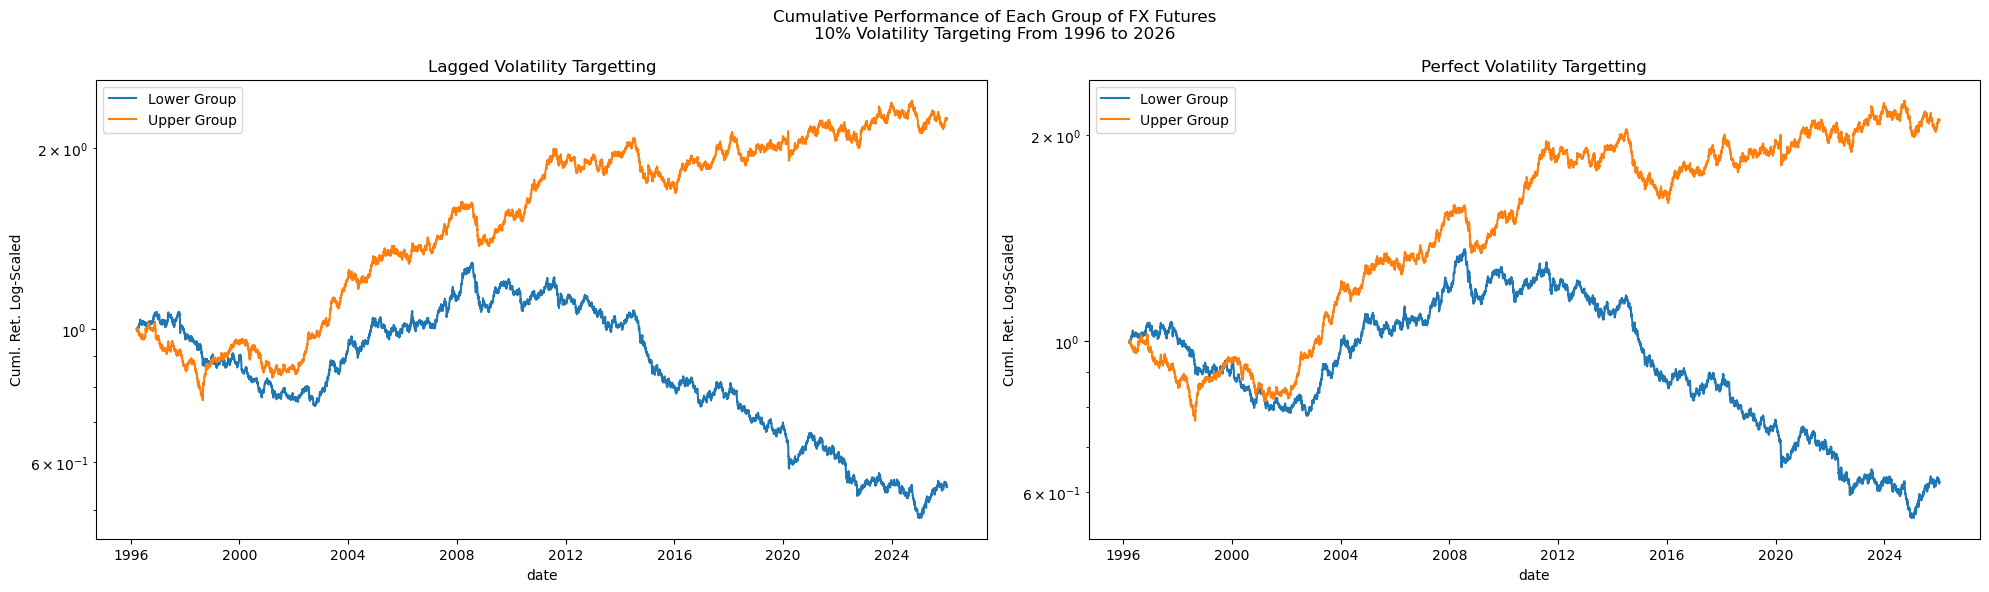

In [13]:
groups    = df_leg_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6))

for group, ax in zip(groups, axes.flatten()): 

    (df_leg_rtn.query(
        "group == @group").
        rename(columns = {"value" : ""}).
        pivot(index = "date", columns = "", values = "rtn").
        rename(columns = {
            "lgroup": "Lower Group",
            "ugroup": "Upper Group"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Performance of Each Group of FX Futures\n10% Volatility Targeting From {} to {}".format(
    df_leg_rtn.date.min().year,
    df_leg_rtn.date.max().year))

plt.tight_layout()
out_path = os.path.join("latex", "LSZscoreRtn.png")
fig.savefig(out_path, dpi = 300)

In [14]:
display(df_leg_rtn.drop(
    columns = ["date"]).
    groupby(["group", "value"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {"value": ""}).
    pivot(index = "group", columns = "", values = "rtn").
    rename(columns = {
        "lgroup": "Lower Group",
        "ugroup": "Upper Group"}).
    apply(lambda x: np.round(x,3)))

,Lower Group,Upper Group
group,,
Lagged,-0.243,0.408
Perfect,-0.195,0.394


In [15]:
df_port = (df_leg_rtn.pivot(
    index = ["date", "group"], columns = "value", values = "rtn").
    assign(spread = lambda x: x.ugroup - x.lgroup).
    reset_index())

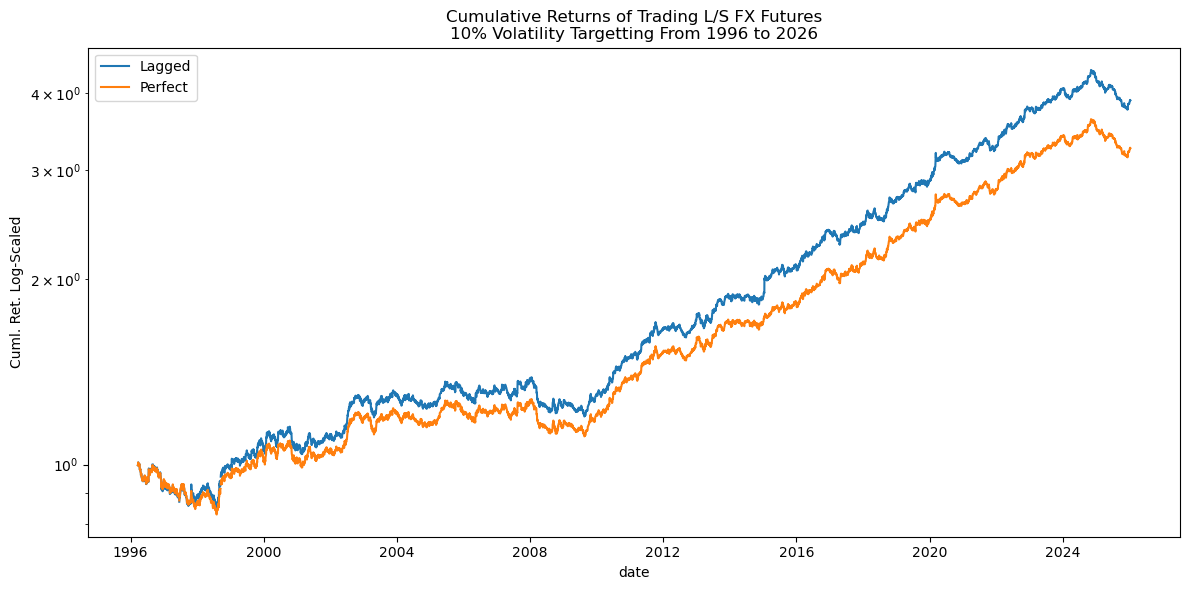

In [16]:
fig, axes = plt.subplots(figsize = (12,6))

(df_port.assign(
    group = lambda x: x.group.str.capitalize()).
    rename(columns = {"group": ""}).
    pivot(index = "date", columns = "", values = "spread").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax      = axes,
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading L/S FX Futures\n10% Volatility Targetting From {} to {}".format(
            df_port.date.min().year,
            df_port.date.max().year)))

plt.tight_layout()

In [17]:
(df_port.assign(
    year = lambda x: pd.to_datetime(x.date).dt.year,
    before = lambda x: np.where(x.year <= 2009, x.spread, np.nan),
    after  = lambda x: np.where(x.year > 2009, x.spread, np.nan)).
    drop(columns = ["lgroup", "ugroup", "year"]).
    melt(id_vars = ["date", "group"], value_name = "rtn").
    drop(columns = ["date"]).
    groupby(["group", "value"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {
        "value": "Period",
        "group": ""}).
    replace({
        "after" : "After 09",
        "before": "Before 09",
        "spread": "Full Period"}).
    pivot(index = "", columns = "Period", values = "rtn").
    apply(lambda x: np.round(x,3)))

Period,After 09,Before 09,Full Period
,,,
Lagged,1.279,0.296,0.745
Perfect,1.242,0.231,0.688


# Residual Cross-Sectional Portfolio

In [18]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.signal)).
        fit().
        resid.
        to_frame(name = "resid"))

    return df_out

df_resid = (df_combined.set_index(
    "date").
    groupby("fut_ticker").
    apply(_get_resid, include_groups = False).
    reset_index())

In [19]:
df_group = (df_resid.pivot(
    index = "date", columns = "fut_ticker", values = "resid").
    assign(med_val = lambda x: x.median(axis = 1)).
    reset_index().
    melt(id_vars = ["date", "med_val"]).
    assign(group = lambda x: np.where(x.value > x.med_val, "ugroup", "lgroup")).
    pivot(index = "date", columns = "fut_ticker", values = "group").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "leg_group"))

In [20]:
df_leg_rtn = (df_vol_combined.merge(
    right = df_group, how = "inner", on = ["date", "fut_ticker"])
    [["date", "group", "rtn", "leg_group"]].
    groupby(["date", "group", "leg_group"]).
    agg("mean").
    reset_index())

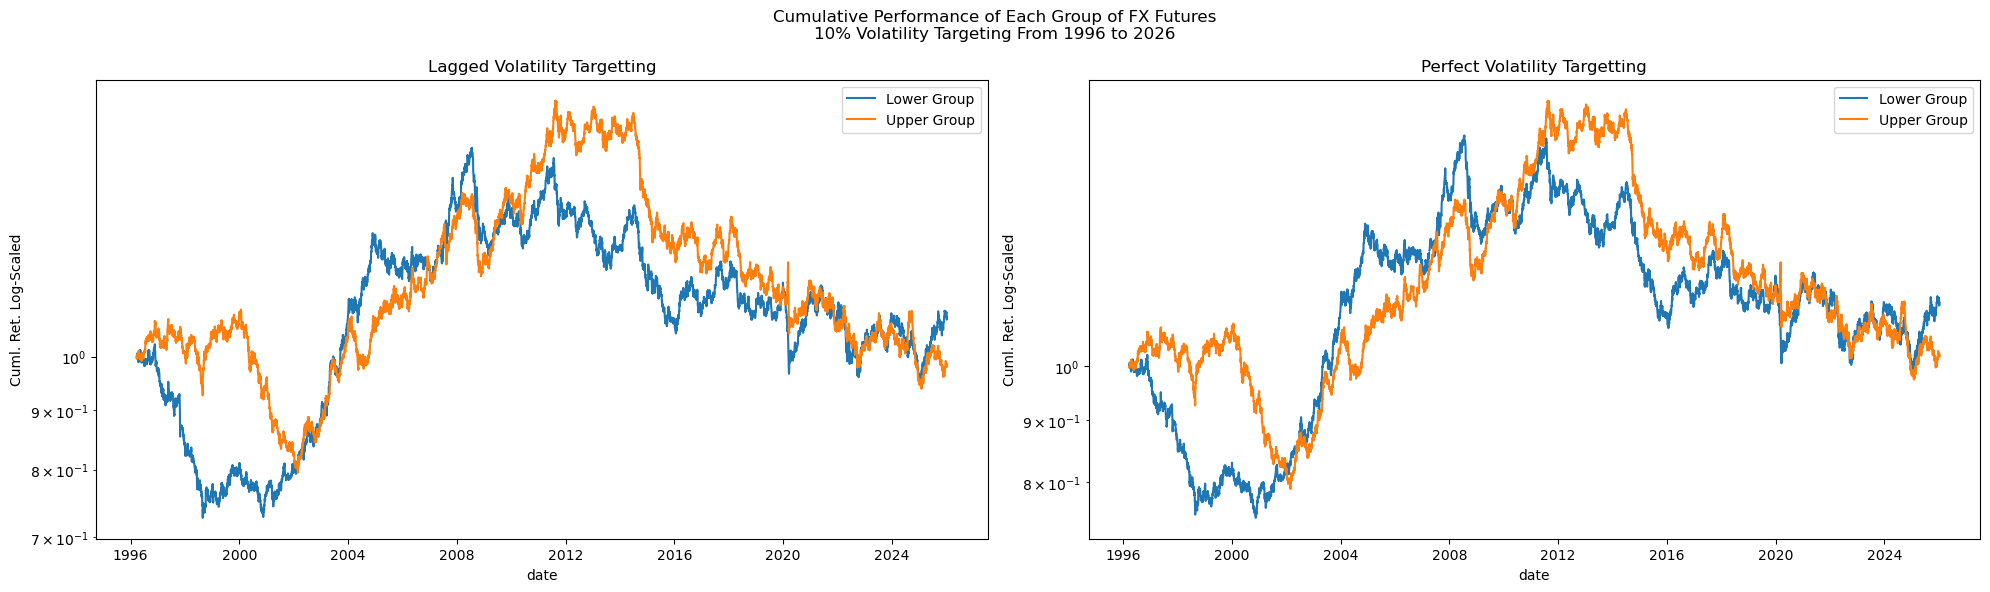

In [21]:
groups    = df_leg_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6))

for group, ax in zip(groups, axes.flatten()): 

    (df_leg_rtn.query(
        "group == @group").
        rename(columns = {"leg_group" : ""}).
        pivot(index = "date", columns = "", values = "rtn").
        rename(columns = {
            "lgroup": "Lower Group",
            "ugroup": "Upper Group"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Performance of Each Group of FX Futures\n10% Volatility Targeting From {} to {}".format(
    df_leg_rtn.date.min().year,
    df_leg_rtn.date.max().year))

plt.tight_layout()

In [22]:
(df_leg_rtn.drop(
    columns = ["date"]).
    groupby(["group", "leg_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {"leg_group": ""}).
    pivot(index = "group", columns = "", values = "rtn").
    rename(columns = {
        "lgroup": "Lower Group",
        "ugroup": "Upper Group"}).
    apply(lambda x: np.round(x,3)))

,Lower Group,Upper Group
group,,
Lagged,0.073,0.030
Perfect,0.093,0.046


In [23]:
df_port = (df_leg_rtn.pivot(
    index = ["date", "group"], columns = "leg_group", values = "rtn").
    assign(spread = lambda x: x.ugroup - x.lgroup).
    reset_index())

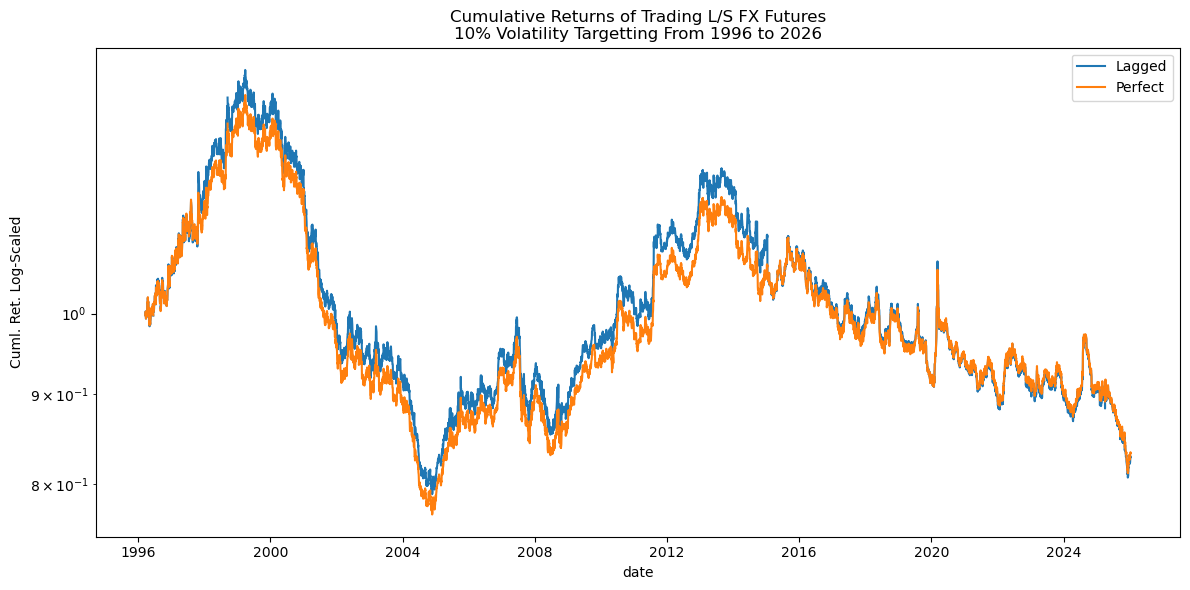

In [24]:
(df_port.assign(
    group = lambda x: x.group.str.capitalize()).
    rename(columns = {"group": ""}).
    pivot(index = "date", columns = "", values = "spread").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (12,6),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading L/S FX Futures\n10% Volatility Targetting From {} to {}".format(
            df_port.date.min().year,
            df_port.date.max().year)))

plt.tight_layout()

In [25]:
(df_port[
    ["group", "spread"]].
    reset_index().
    melt(id_vars = "group").
    query("leg_group != 'index'").
    drop(columns = ["leg_group"]).
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {"group": "Group"}).
    groupby("Group").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"value": "Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Sharpe
Group,
Lagged,-0.056
Perfect,-0.061
